In [6]:
# ==============================================================================
# CELL 0 & 1: BOOTSTRAP, VISUAL CANON & GRAND JOIN (SOP 0401)
# ==============================================================================
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# --- 1. HYGIENE & DIRECTORIES ---
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
pd.options.mode.chained_assignment = None

DUMP_DIR = '/workspaces/pienza/data/dumped_files'
os.makedirs(DUMP_DIR, exist_ok=True)

# --- 2. THE VISUAL CANON (COLORES MAESTROS) ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GRAY   = '#555555'
OPUS_BG     = '#FAFAFA'
OPUS_TEXT   = '#121212'

# Aplicar el tema global a Matplotlib/Seaborn
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_BG,
    'axes.facecolor': OPUS_BG,
    'text.color': OPUS_TEXT,
    'xtick.color': OPUS_GRAY,
    'ytick.color': OPUS_GRAY,
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 24,
    'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Opus Lab (Master Palette Active).")

# --- 3. CONNECTIVITY & DATA INGESTION ---
DB_PATH = '/workspaces/pienza/data/pienza.db'
if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
else:
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print(f"✅ SQL Engine Active: {DB_PATH}")

print("\n⏳ Executing The Grand Join (Offers + Engineered Features)...")
query = """
SELECT o.*, ef.*
FROM offers o
LEFT JOIN engineered_features ef ON o.offer_id = ef.offer_id_fk
"""

try:
    df_grand = pd.read_sql(query, db_engine)
    # Limpieza de duplicados por JOIN
    df_grand = df_grand.loc[:, ~df_grand.columns.duplicated()]
    print(f"✅ Grand Table Loaded. Shape: {df_grand.shape}")
    
except Exception as e:
    print(f"🔴 SQL Error: {e}")

print("\n--- SYSTEM READY ---")

✅ Visual Identity Loaded: Opus Lab (Master Palette Active).
✅ SQL Engine Active: /workspaces/pienza/data/pienza.db

⏳ Executing The Grand Join (Offers + Engineered Features)...
✅ Grand Table Loaded. Shape: (4765, 95)

--- SYSTEM READY ---


In [7]:
# ==============================================================================
# CELL 1: THE GRAND JOIN & NULL AUDIT (CORRECTED)
# ==============================================================================

print("⏳ Executing The Grand Join (Offers + Engineered Features)...")

# Correction: Added comma between select blocks
query = """
SELECT
    o.*,
    ef.*
FROM offers o
LEFT JOIN engineered_features ef ON o.offer_id = ef.offer_id_fk
"""

try:
    df_grand = pd.read_sql(query, db_engine)

    # Cleanup: Drop duplicate columns (offer_id vs offer_id_fk)
    # This keeps the first occurrence and drops subsequent columns with same name if any,
    # but more importantly, we know offer_id_fk is redundant if we have offer_id.
    df_grand = df_grand.loc[:, ~df_grand.columns.duplicated()]

    print(f"✅ Grand Table Loaded. Shape: {df_grand.shape}")

    # Null Audit
    print("\n🔍 NULL AUDIT REPORT:")
    null_counts = df_grand.isnull().sum()
    null_report = pd.DataFrame({'Missing Values': null_counts, '% Missing': (null_counts / len(df_grand)) * 100})
    print(null_report[null_report['Missing Values'] > 0].sort_values('% Missing', ascending=False))

except Exception as e:
    print(f"🔴 SQL Error: {e}")

⏳ Executing The Grand Join (Offers + Engineered Features)...
✅ Grand Table Loaded. Shape: (4765, 95)

🔍 NULL AUDIT REPORT:
                              Missing Values  % Missing
comment_2                               4764  99.979014
reservation_amount                      4607  96.684155
priority_amount                         4592  96.369360
comment_1                               4535  95.173137
outcome_fk                              4418  92.717733
dispatch_lead_time_sec                  3539  74.270724
turbo_plus_amount                       3429  71.962225
surge_amount                            3256  68.331584
eph_realized_ML                         1477  30.996852
eph_realized_index_ML                   1477  30.996852
is_spread_downgrade_ML                  1477  30.996852
eph_complete_ML                         1477  30.996852
is_total_cycle_downgrade_ML             1477  30.996852
eph_complete_index_ML                   1477  30.996852
cycle_rolling_avg_spread             

In [8]:
# ==============================================================================
# CELL 2: THE VARIANCE FILTER (KILLING ZOMBIES)
# ==============================================================================
from sklearn.feature_selection import VarianceThreshold

print("⏳ Preparing Data for Feature Selection...")

# 1. Create the Analytical Matrix (Numeric Only)
# We exclude IDs and Targets for this check
numeric_cols = df_grand.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ['offer_id', 'session_id', 'ocr_id', 'offer_action_fk', 'record_status_fk',
                'outcome_fk', 'reason_primary_fk', 'product_category_fk', # IDs treated as numbers
                'image_content_hash'] # Not relevant for variance

X_analysis = df_grand[numeric_cols].drop(columns=exclude_cols, errors='ignore')

# 2. Tactical Imputation (For Calculation Only)
# Logic: If an amount is missing, it's 0. If a flag is missing, it's 0.
# For rates/indices, 0 is dangerous, but for Variance checking, it usually works
# to identify constants.
X_filled = X_analysis.fillna(0)

print(f"   -> Analyzing {X_filled.shape[1]} numeric features for variance...")

# 3. Apply Variance Threshold
# Threshold = 0 means "Remove columns that have the same value in all samples"
selector = VarianceThreshold(threshold=0)
selector.fit(X_filled)

# 4. Identify Zombies
features_all = X_filled.columns
features_kept = features_all[selector.get_support()]
features_dead = features_all[~selector.get_support()]

print(f"\n💀 ZOMBIE FEATURES DETECTED: {len(features_dead)}")
if len(features_dead) > 0:
    print(list(features_dead))
    print("   -> Recommendation: DROP immediately.")
else:
    print("   -> All features have some variance. No flatliners.")

# 5. Low Variance Check (Quasi-Constant)
# Let's check for features that are 99% constant (almost dead)
# This is manual because VarianceThreshold uses raw variance, which is scale-dependent.
print("\n📉 QUASI-CONSTANT CHECK (99% same value):")
quasi_constants = []
for col in features_kept:
    # Calculate percentage of the most frequent value
    top_val_pct = (X_filled[col].value_counts(normalize=True).iloc[0]) * 100
    if top_val_pct > 99:
        quasi_constants.append((col, top_val_pct))

if quasi_constants:
    for col, pct in quasi_constants:
        print(f"   - {col}: {pct:.2f}% identical values (Candidate for drop)")
else:
    print("   -> No quasi-constant features found.")

⏳ Preparing Data for Feature Selection...
   -> Analyzing 67 numeric features for variance...

💀 ZOMBIE FEATURES DETECTED: 0
   -> All features have some variance. No flatliners.

📉 QUASI-CONSTANT CHECK (99% same value):
   - is_teens: 99.62% identical values (Candidate for drop)
   - is_imputed: 99.60% identical values (Candidate for drop)


In [9]:
# ==============================================================================
# CELL 3: PRUNING THE QUASI-CONSTANTS
# ==============================================================================

# 1. Define the Kill List
cols_to_drop = ['is_teens', 'is_imputed']

# 2. Execute Drop on the Master DataFrame
print(f"✂️ Dropping quasi-constant features: {cols_to_drop}...")
df_grand = df_grand.drop(columns=cols_to_drop, errors='ignore')

# 3. Update our analysis list (X_analysis) for the next step
# We need to refresh this list so the next step doesn't look for dead columns
numeric_cols = df_grand.select_dtypes(include=[np.number]).columns.tolist()
# Re-apply exclusions
exclude_cols = ['offer_id', 'session_id', 'ocr_id', 'offer_action_fk', 'record_status_fk',
                'outcome_fk', 'reason_primary_fk', 'product_category_fk', 'image_content_hash']
X_analysis = df_grand[numeric_cols].drop(columns=exclude_cols, errors='ignore')

print(f"✅ Pruning Complete. Current Feature Count: {X_analysis.shape[1]}")
print("\n--- READY FOR CORRELATION ANALYSIS ---")

✂️ Dropping quasi-constant features: ['is_teens', 'is_imputed']...
✅ Pruning Complete. Current Feature Count: 65

--- READY FOR CORRELATION ANALYSIS ---


⏳ Calculating Correlation Matrix...


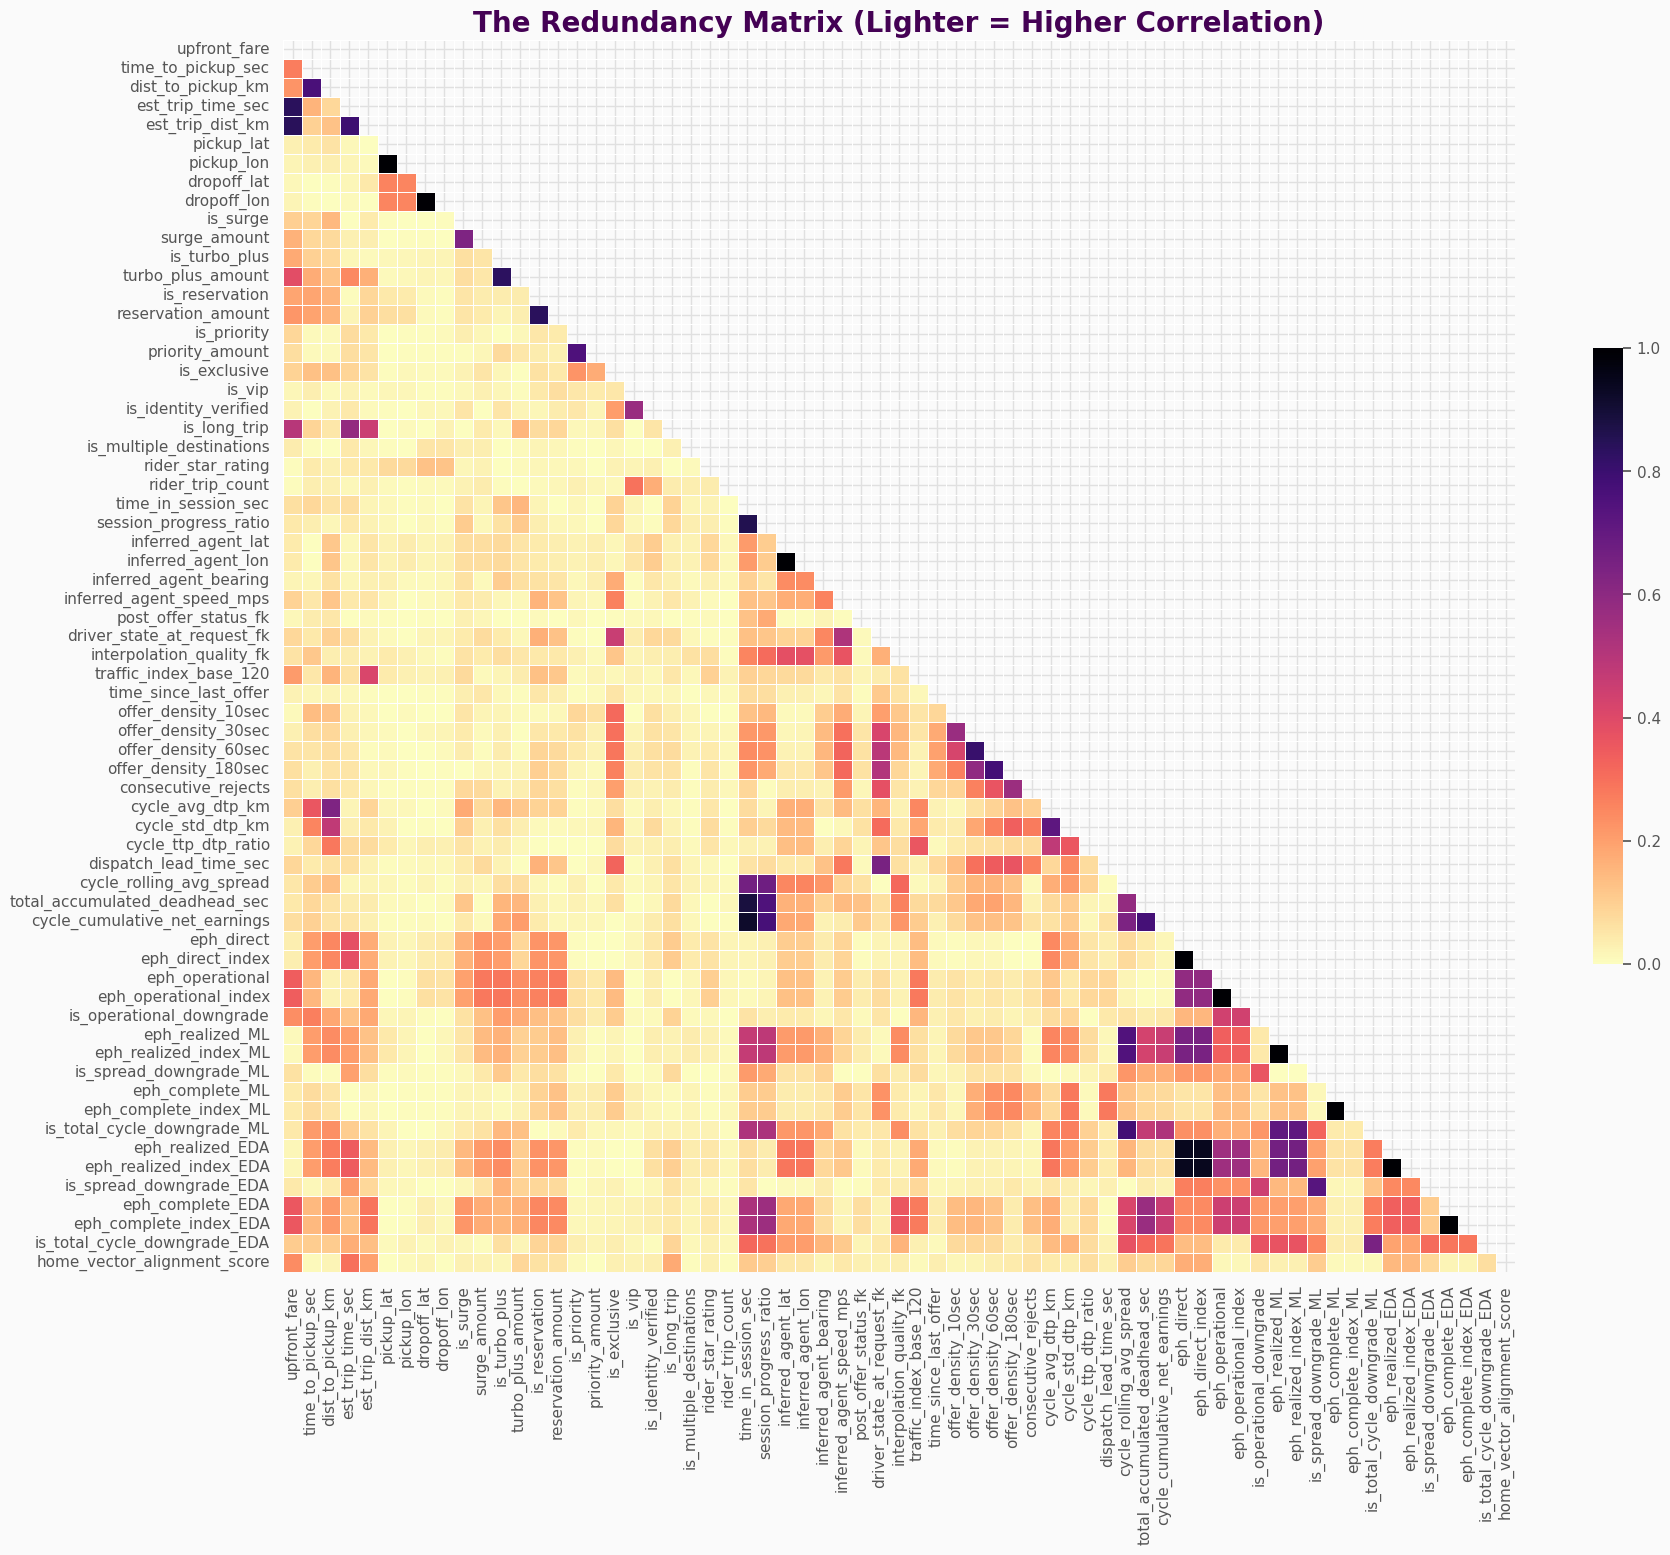


🚨 HIGH REDUNDANCY ALERT (Correlation > 0.9):
These pairs are mathematically nearly identical. You must choose ONE.
------------------------------------------------------------
🔗 eph_complete_EDA  <-->  eph_complete_index_EDA 	 (r = 1.0000)
🔗 eph_realized_EDA  <-->  eph_realized_index_EDA 	 (r = 1.0000)
🔗 eph_complete_ML  <-->  eph_complete_index_ML 	 (r = 1.0000)
🔗 eph_realized_ML  <-->  eph_realized_index_ML 	 (r = 1.0000)
🔗 eph_operational  <-->  eph_operational_index 	 (r = 1.0000)
🔗 eph_direct  <-->  eph_direct_index 	 (r = 1.0000)
🔗 inferred_agent_lat  <-->  inferred_agent_lon 	 (r = 1.0000)
🔗 pickup_lat  <-->  pickup_lon 	 (r = 0.9968)
🔗 dropoff_lat  <-->  dropoff_lon 	 (r = 0.9943)
🔗 eph_direct  <-->  eph_realized_index_EDA 	 (r = 0.9429)
🔗 eph_direct  <-->  eph_realized_EDA 	 (r = 0.9429)
🔗 eph_direct_index  <-->  eph_realized_index_EDA 	 (r = 0.9429)
🔗 eph_direct_index  <-->  eph_realized_EDA 	 (r = 0.9429)
🔗 time_in_session_sec  <-->  cycle_cumulative_net_earnings 	 (r = 0.9

In [10]:
# ==============================================================================
# CELL 4: THE CORRELATION SCAN (FINDING DOPPELGÄNGERS)
# ==============================================================================

print("⏳ Calculating Correlation Matrix...")

# 1. Calculate Correlation (using filled data for consistency)
# We focus on the independent variables, but keeping targets helps see relevance.
corr_matrix = X_analysis.fillna(0).corr().abs()

# 2. The Heatmap Visualization
plt.figure(figsize=(20, 16))
# Mask the upper triangle (it's redundant)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, cmap='magma_r', vmax=1, vmin=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

plt.title("The Redundancy Matrix (Lighter = Higher Correlation)", fontsize=20, color=OPUS_PURPLE, fontweight='bold')
plt.show()

# 3. The "Kill List" Report (Programmatic Detection)
# Find pairs with correlation > 0.90
threshold = 0.90
print(f"\n🚨 HIGH REDUNDANCY ALERT (Correlation > {threshold}):")
print("These pairs are mathematically nearly identical. You must choose ONE.")
print("-" * 60)

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

# Logic to print the specific pairs
pairs = []
for column in upper.columns:
    for index in upper.index:
        if upper.loc[index, column] > threshold:
            pairs.append((index, column, upper.loc[index, column]))

# Sort by correlation strength (highest first)
pairs.sort(key=lambda x: x[2], reverse=True)

for p in pairs:
    print(f"🔗 {p[0]}  <-->  {p[1]} \t (r = {p[2]:.4f})")

print("-" * 60)
print(f"Total High-Correlation Pairs detected: {len(pairs)}")

Detected 8 EDA features to drop:
['eph_realized_EDA', 'eph_realized_index_EDA', 'eph_realized_label_EDA', 'is_spread_downgrade_EDA', 'eph_complete_EDA', 'eph_complete_index_EDA', 'eph_complete_label_EDA', 'is_total_cycle_downgrade_EDA']

✂️ Purging EDA columns from Master Table...
✅ Purge Complete. Current Feature Count: 59

⏳ Re-calculating Correlation Matrix (Post-Purge)...


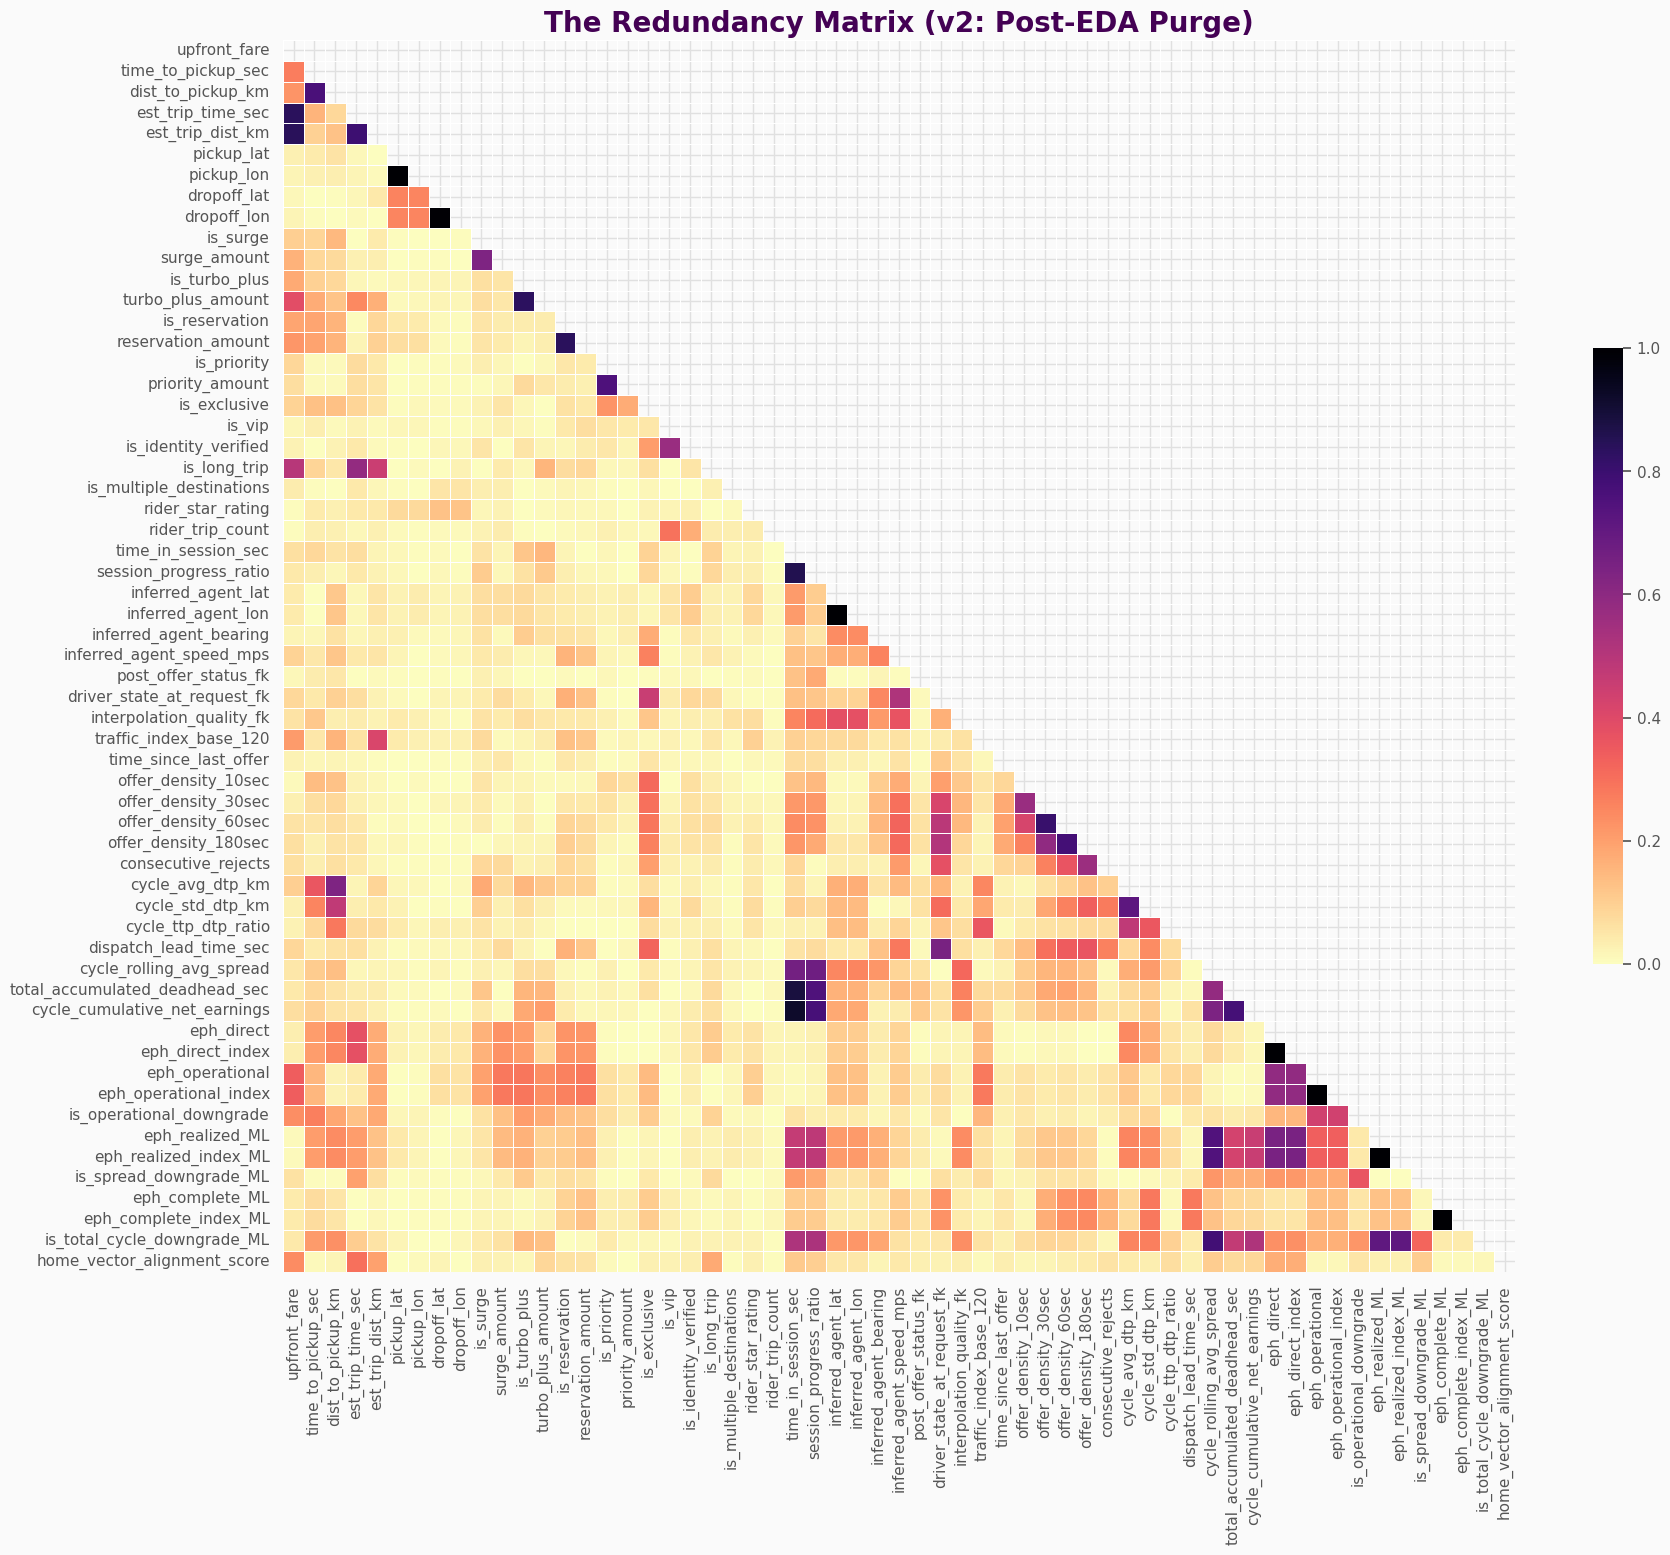


🚨 HIGH REDUNDANCY ALERT v2 (Correlation > 0.9):
🔗 eph_complete_ML  <-->  eph_complete_index_ML 	 (r = 1.0000)
🔗 eph_realized_ML  <-->  eph_realized_index_ML 	 (r = 1.0000)
🔗 eph_operational  <-->  eph_operational_index 	 (r = 1.0000)
🔗 eph_direct  <-->  eph_direct_index 	 (r = 1.0000)
🔗 inferred_agent_lat  <-->  inferred_agent_lon 	 (r = 1.0000)
🔗 pickup_lat  <-->  pickup_lon 	 (r = 0.9968)
🔗 dropoff_lat  <-->  dropoff_lon 	 (r = 0.9943)
🔗 time_in_session_sec  <-->  cycle_cumulative_net_earnings 	 (r = 0.9201)
------------------------------------------------------------
Remaining High-Correlation Pairs: 8


In [11]:
# ==============================================================================
# CELL 5: THE EDA PURGE & RE-SCAN
# ==============================================================================

# 1. Identify EDA Columns (The Leakage Vectors)
eda_cols = [col for col in df_grand.columns if col.endswith('_EDA')]

print(f"Detected {len(eda_cols)} EDA features to drop:")
print(eda_cols)

# 2. Execute the Drop
print("\n✂️ Purging EDA columns from Master Table...")
df_grand = df_grand.drop(columns=eda_cols, errors='ignore')

# 3. Refresh X_analysis (The clean numeric matrix)
# We rebuild the list of numeric columns based on the new df_grand
numeric_cols = df_grand.select_dtypes(include=[np.number]).columns.tolist()
# Re-apply standard exclusions (IDs and Keys)
exclude_cols = ['offer_id', 'session_id', 'ocr_id', 'offer_action_fk', 'record_status_fk',
                'outcome_fk', 'reason_primary_fk', 'product_category_fk', 'image_content_hash']
X_analysis = df_grand[numeric_cols].drop(columns=exclude_cols, errors='ignore')

print(f"✅ Purge Complete. Current Feature Count: {X_analysis.shape[1]}")


# 4. RE-RUN CORRELATION SCAN (The Clean View)
print("\n⏳ Re-calculating Correlation Matrix (Post-Purge)...")
corr_matrix = X_analysis.fillna(0).corr().abs()

# Visualization
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='magma_r', vmax=1, vmin=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title("The Redundancy Matrix (v2: Post-EDA Purge)", fontsize=20, color=OPUS_PURPLE, fontweight='bold')
plt.show()

# Report
threshold = 0.90
print(f"\n🚨 HIGH REDUNDANCY ALERT v2 (Correlation > {threshold}):")
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
pairs = []
for column in upper.columns:
    for index in upper.index:
        if upper.loc[index, column] > threshold:
            pairs.append((index, column, upper.loc[index, column]))

pairs.sort(key=lambda x: x[2], reverse=True)

if not pairs:
    print("✅ No extreme redundancy detected.")
else:
    for p in pairs:
        print(f"🔗 {p[0]}  <-->  {p[1]} \t (r = {p[2]:.4f})")
    print("-" * 60)
    print(f"Remaining High-Correlation Pairs: {len(pairs)}")

# 🩺 DIAGNÓSTICO Y ORDEN DE BATALLA: La Cirugía de Redundancia

Tras el análisis de correlación, hemos identificado tres clusters críticos de redundancia matemática. A continuación se detalla la decisión estratégica para cada caso, priorizando la señal predictiva sobre la repetición.

### **CASO 1: La Crisis de Identidad (Raw vs. Index)**
*   **El Hecho:** `eph_direct` vs `eph_direct_index` presentan una correlación de **r=1.0**. Son funcionalmente idénticos; uno es una transformación lineal del otro.
*   **La Decisión:** 💀 **ELIMINAR LOS RAW (`eph_direct`, etc). CONSERVAR LOS INDEX.**
*   **El Porqué:** Los índices (`_index`) ya están normalizados en torno a la "North Star" ($200 MXN/hr). Un valor de `0.8` comunica instantáneamente "80% de la meta", facilitando la interpretabilidad. Además, al estar en una escala pequeña y estandarizada (~0 a 3), se comportan mejor numéricamente para los algoritmos de ML que los valores crudos en pesos.

### **CASO 2: El Dilema Geográfico (Lat vs. Lon)**
*   **El Hecho:** `lat` vs `lon` muestran una correlación casi perfecta. Esto refleja la morfología diagonal de la CDMX (suroeste a noreste).
*   **La Decisión:** 🛡️ **INDULTO TEMPORAL (NO TOCAR).**
*   **La Estrategia:** Aunque son matemáticamente redundantes, son **geométricamente indispensables**. No podemos realizar el **Clustering Espacial (Stage 2)** con una sola coordenada. Estas variables se mantendrán hasta que sean transformadas en `Zone_ID` o clusters latentes, momento en el cual se eliminarán las coordenadas crudas.

### **CASO 3: Tiempo vs. Dinero**
*   **El Hecho:** `time_in_session_sec` vs `cycle_cumulative_net_earnings` (**r=0.92**). La acumulación de dinero es una función casi lineal del tiempo invertido.
*   **La Decisión:** 💀 **ELIMINAR `time_in_session_sec`. CONSERVAR `cumulative_earnings`.**
*   **La Estrategia:** Desde una perspectiva conductual, la **meta económica** es un driver psicológico más fuerte que el simple reloj. El dinero captura el "valor" del tiempo invertido. Además, la dimensión temporal relativa ya está perfectamente capturada por la feature `session_progress_ratio`, haciendo que el tiempo absoluto sea redundante.

In [12]:
# ==============================================================================
# CELL 6: THE SURGICAL STRIKE (REDUNDANCY ELIMINATION)
# ==============================================================================

# 1. Define the Kill List (Based on Strategic Analysis)
redundant_cols = [
    # Group 1: Dropping Raw EPHs (Keeping Indices)
    'eph_direct',
    'eph_operational',
    'eph_realized_ML',
    'eph_complete_ML',

    # Group 3: Dropping Time (Keeping Earnings & Ratios)
    'time_in_session_sec'
    # Note: We keep session_progress_ratio as it is normalized (0-1)
]

# 2. Execute Drop
print(f"✂️ Executing Surgical Strike on {len(redundant_cols)} redundant features...")
df_grand = df_grand.drop(columns=redundant_cols, errors='ignore')

# 3. Refresh Analysis Matrix
numeric_cols = df_grand.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ['offer_id', 'session_id', 'ocr_id', 'offer_action_fk', 'record_status_fk',
                'outcome_fk', 'reason_primary_fk', 'product_category_fk', 'image_content_hash']
X_analysis = df_grand[numeric_cols].drop(columns=exclude_cols, errors='ignore')

print(f"✅ Surgery Successful. Final Feature Count: {X_analysis.shape[1]}")

# 4. Final Sanity Check on what remains
print("\n🧬 SURVIVING FEATURE SET (Sample):")
print(X_analysis.columns.tolist()[:10], "...")

✂️ Executing Surgical Strike on 5 redundant features...
✅ Surgery Successful. Final Feature Count: 54

🧬 SURVIVING FEATURE SET (Sample):
['upfront_fare', 'time_to_pickup_sec', 'dist_to_pickup_km', 'est_trip_time_sec', 'est_trip_dist_km', 'pickup_lat', 'pickup_lon', 'dropoff_lat', 'dropoff_lon', 'is_surge'] ...



### 🛡️ OPERACIÓN: Selección de Características vía Lasso Logístico (L1)

**Objetivo Estratégico:**
Identificar las variables que realmente "mueven la aguja" en la toma de decisiones del Agente. 

**Nota de Versión:** Se ha eliminado `multi_class='multinomial'` ya que las versiones actuales de sklearn lo infieren automáticamente a partir del target `y`.


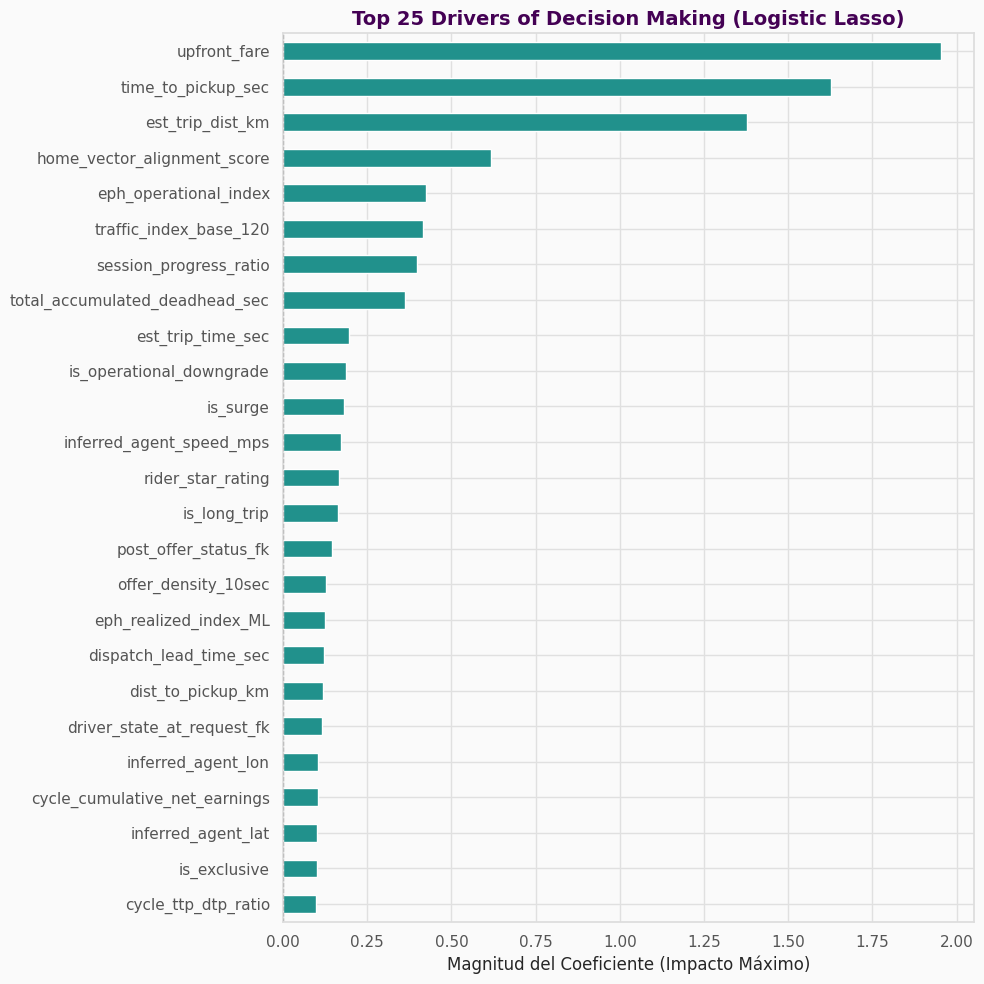


### 🏆 Resultados del Torneo

*   **Supervivientes (Señal):** `48` variables con utilidad predictiva.
*   **Bajas (Ruido):** `4` variables reducidas a cero.

**La Lista de Bajas:**
`['pickup_lat', 'pickup_lon', 'is_reservation', 'offer_density_180sec']`


In [14]:
# ==============================================================================
# CELL 7: THE LOGISTIC LASSO TOURNAMENT (CLASSIFICATION IMPACT) - FIXED
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from IPython.display import display, Markdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. STRATEGIC PREAMBLE ---
display(Markdown("""
### 🛡️ OPERACIÓN: Selección de Características vía Lasso Logístico (L1)

**Objetivo Estratégico:**
Identificar las variables que realmente "mueven la aguja" en la toma de decisiones del Agente. 

**Nota de Versión:** Se ha eliminado `multi_class='multinomial'` ya que las versiones actuales de sklearn lo infieren automáticamente a partir del target `y`.
"""))

# --- 2. DATA PREPARATION ---
# Construct Target (y)
y_raw = df_grand['reason_primary_fk'].fillna(9999)
le = LabelEncoder()
y = le.fit_transform(y_raw)

# Construct Features (X)
drop_for_training = [
    'offer_id', 'session_id', 'ocr_id', 'offer_action_fk', 'record_status_fk',
    'outcome_fk', 'reason_primary_fk', 'product_category_fk', 'image_content_hash',
    'special_note_raw', 'comment_1', 'comment_2',
    'pickup_address', 'dropoff_address',
    'is_spread_downgrade_ML', 'is_total_cycle_downgrade_ML'
]
X = df_grand.drop(columns=drop_for_training, errors='ignore').select_dtypes(include=[np.number])
X = X.fillna(0) # Tactical imputation

# Standardization (Critical for Lasso)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 3. MODEL EXECUTION ---
# C=0.05 implica una penalización fuerte para forzar la "muerte" de variables débiles.
# solver='saga' es el estándar de oro para L1 en datasets grandes.
model = LogisticRegression(
    penalty='l1', 
    C=0.05, 
    solver='saga', 
    max_iter=5000, 
    random_state=42
)
model.fit(X_scaled, y)

# --- 4. RESULT EXTRACTION ---
# Tomamos el impacto máximo absoluto a través de todas las clases de decisión.
max_coefs = np.max(np.abs(model.coef_), axis=0)
feature_importance = pd.Series(max_coefs, index=X.columns)

survivors = feature_importance[feature_importance > 0].sort_values(ascending=False)
casualties = feature_importance[feature_importance == 0]

# --- 5. VISUALIZATION ---
plt.figure(figsize=(10, 10))
# Usamos OPUS_TEAL si está definido, o el hex directamente
color_bar = OPUS_TEAL if 'OPUS_TEAL' in locals() else '#21918c'

survivors.head(25).sort_values().plot(kind='barh', color=color_bar)
plt.title("Top 25 Drivers of Decision Making (Logistic Lasso)", fontsize=14, fontweight='bold', color=OPUS_PURPLE if 'OPUS_PURPLE' in locals() else '#440154')
plt.xlabel("Magnitud del Coeficiente (Impacto Máximo)")
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

# Narrative Output
display(Markdown(f"""
### 🏆 Resultados del Torneo

*   **Supervivientes (Señal):** `{len(survivors)}` variables con utilidad predictiva.
*   **Bajas (Ruido):** `{len(casualties)}` variables reducidas a cero.

**La Lista de Bajas:**
`{list(casualties.index)}`
"""))


### 🥊 OPERACIÓN: Cage Match (Tiempo vs. Distancia)

**El Conflicto:**
Lasso seleccionó `est_trip_dist_km` como un driver superior a `est_trip_time_sec`.
Sin embargo, el **Conocimiento de Dominio del Arquitecto** dicta que el Tiempo es el verdadero costo operativo (especialmente con EV), y que la Distancia es solo un proxy estable.

**El Experimento:**
Ejecutamos una segunda ronda de Lasso **eliminando explícitamente la Distancia**.
*   **Hipótesis:** `est_trip_time_sec` debería absorber la importancia de la distancia y subir al Top.
*   **Criterio de Decisión:** Si este modelo alternativo mantiene la coherencia, validamos el "Domain Override" y forzamos el uso del Tiempo.


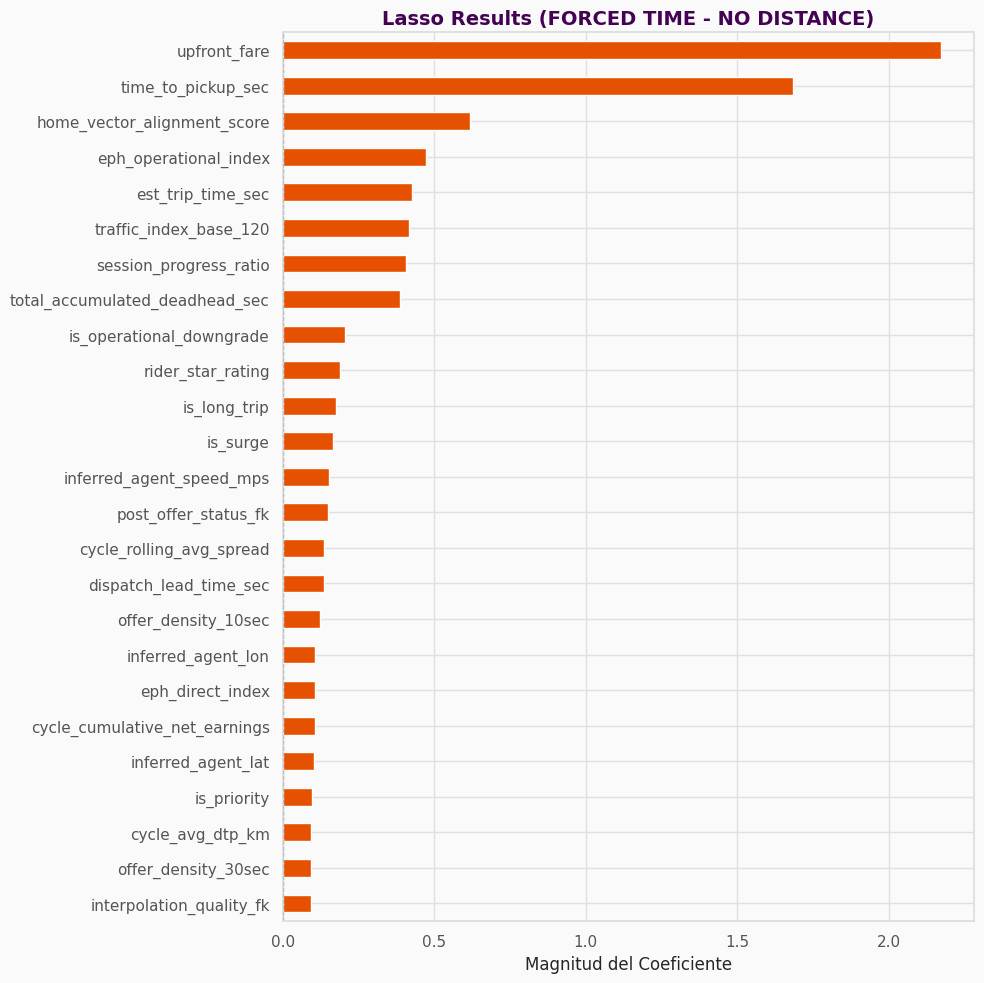

**Resultado para `est_trip_time_sec`:**
- Nuevo Ranking: **#5**
- Coeficiente: `0.4252`

In [16]:
# ==============================================================================
# CELL 8: THE DOMAIN INTERVENTION (TIME VS DISTANCE CAGE MATCH) - FIXED
# ==============================================================================

from IPython.display import display, Markdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

display(Markdown("""
### 🥊 OPERACIÓN: Cage Match (Tiempo vs. Distancia)

**El Conflicto:**
Lasso seleccionó `est_trip_dist_km` como un driver superior a `est_trip_time_sec`.
Sin embargo, el **Conocimiento de Dominio del Arquitecto** dicta que el Tiempo es el verdadero costo operativo (especialmente con EV), y que la Distancia es solo un proxy estable.

**El Experimento:**
Ejecutamos una segunda ronda de Lasso **eliminando explícitamente la Distancia**.
*   **Hipótesis:** `est_trip_time_sec` debería absorber la importancia de la distancia y subir al Top.
*   **Criterio de Decisión:** Si este modelo alternativo mantiene la coherencia, validamos el "Domain Override" y forzamos el uso del Tiempo.
"""))

# 1. Create a View without Distance
# Intentionally dropping the strong predictors to see if the weaker one steps up
# Ensure that 'X' is available from Cell 7
if 'X' in locals():
    X_time_only = X.drop(columns=['est_trip_dist_km', 'dist_to_pickup_km'], errors='ignore')

    # 2. Standardize
    scaler_time = StandardScaler()
    X_time_scaled = scaler_time.fit_transform(X_time_only)

    # 3. Train Lasso Variant
    # FIXED: Removed 'multi_class=multinomial' for sklearn v1.5+ compatibility
    model_time = LogisticRegression(
        penalty='l1', 
        C=0.05, 
        solver='saga', 
        max_iter=5000, 
        random_state=42
    )
    
    # Ensure 'y' is available from Cell 7
    if 'y' in locals():
        model_time.fit(X_time_scaled, y)

        # 4. Extract Results
        max_coefs_time = np.max(np.abs(model_time.coef_), axis=0)
        feature_importance_time = pd.Series(max_coefs_time, index=X_time_only.columns)
        survivors_time = feature_importance_time[feature_importance_time > 0].sort_values(ascending=False)

        # 5. Visualization
        plt.figure(figsize=(10, 10))
        survivors_time.head(25).sort_values().plot(kind='barh', color='#E65100') # Safety Orange for Intervention
        
        # Color definition fallback
        c_title = OPUS_PURPLE if 'OPUS_PURPLE' in locals() else '#440154'
        
        plt.title("Lasso Results (FORCED TIME - NO DISTANCE)", fontsize=14, fontweight='bold', color=c_title)
        plt.xlabel("Magnitud del Coeficiente")
        plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
        plt.tight_layout()
        plt.show()

        # 6. Check the Rank of Time
        try:
            rank_time = survivors_time.index.get_loc('est_trip_time_sec') + 1
            coef_time = survivors_time['est_trip_time_sec']
            display(Markdown(f"**Resultado para `est_trip_time_sec`:**\n- Nuevo Ranking: **#{rank_time}**\n- Coeficiente: `{coef_time:.4f}`"))
        except KeyError:
            display(Markdown("**Resultado:** `est_trip_time_sec` fue eliminado incluso sin distancia. (Esto sería sorprendente y preocupante)."))
    else:
        print("🔴 ERROR: Target variable 'y' not found in memory. Run Cell 7 first.")
else:
    print("🔴 ERROR: Features matrix 'X' not found in memory. Run Cell 7 first.")

In [ ]:
# ==============================================================================
# CELL 9: THE FINAL SELECTION & EXPORT (X_FINAL)
# ==============================================================================

display(Markdown("""
### 💎 OPERACIÓN FINAL: Cristalización del Dataset

**Criterios de Selección Final:**
1.  **Base:** Sobrevivientes del Torneo Lasso (Coeficiente > 0).
2.  **Override 1 (Física):** Se elimina `est_trip_dist_km` por redundancia. Se conserva `est_trip_time_sec` (Costo Real EV).
3.  **Override 2 (Psicología):** Se elimina `rider_star_rating`. El Arquitecto confirma "ceguera cognitiva" a esta variable; cualquier señal estadística es espuria.

**Objetivo:**
Generar la matriz `X_final` limpia, escalada y lista para el entrenamiento del modelo en la Fase 2.
"""))

# 1. Define the Master List manually based on our decisions
# We take the top survivors from the previous step, apply our swaps, and ensure no leakage.
final_features = [
    # --- The Economic Core ---
    'upfront_fare',
    'eph_operational_index', # Relative quality
    'is_surge',

    # --- The Operational Cost ---
    'time_to_pickup_sec',
    'est_trip_time_sec', # The chosen cost metric (vs distance)

    # --- The Strategic Context ---
    'home_vector_alignment_score', # Endgame strategy
    'session_progress_ratio', # Fatigue/Timing
    'traffic_index_base_120', # Friction
    'total_accumulated_deadhead_sec', # Sunk Cost
    'consecutive_rejects', # Frustration/Momentum

    # --- Market Pressure ---
    'offer_density_10sec', # Immediate pressure
    'time_since_last_offer', # Silence/Patience
    'dispatch_lead_time_sec', # Chained trip urgency

    # --- Trip Characteristics ---
    'is_long_trip', # Variance risk proxy
    'is_exclusive', # Product type proxy? Or distinct?
    'is_operational_downgrade', # The bait check

    # --- Supply/Demand Proxies ---
    'cycle_ttp_dtp_ratio',
    'cycle_avg_dtp_km',
    'inferred_agent_speed_mps'
]

# 2. Extract and Verify
print(f"Locked in {len(final_features)} Final Features.")

# Create the final dataframe subset
X_final_raw = df_grand[final_features].copy()

# 3. Handle any remaining NaNs (Tactical Fill)
# Most should be 0 (e.g., dispatch_lead_time), but let's be sure.
X_final_filled = X_final_raw.fillna(0)

# 4. Final Standardization (The "Silver -> Gold" Polish)
scaler_final = StandardScaler()
X_final_scaled = pd.DataFrame(
    scaler_final.fit_transform(X_final_filled),
    columns=final_features,
    index=X_final_filled.index
)

# 5. Add back the Target for the complete export
# We keep the raw target ID for classification
df_export = X_final_scaled.copy()
df_export['target_reason'] = df_grand['reason_primary_fk'].fillna(9999) # 9999 = Accepted

print("✅ X_FINAL Matrix Created and Scaled.")
print(df_export.head())



### 💎 OPERACIÓN FINAL: Cristalización del Dataset

**Criterios de Selección Final:**
1.  **Base:** Sobrevivientes del Torneo Lasso (Coeficiente > 0).
2.  **Override 1 (Física):** Se elimina `est_trip_dist_km` por redundancia. Se conserva `est_trip_time_sec` (Costo Real EV).
3.  **Override 2 (Psicología):** Se elimina `rider_star_rating`. El Arquitecto confirma "ceguera cognitiva" a esta variable; cualquier señal estadística es espuria.

**Objetivo:**
Generar la matriz `X_final` limpia, escalada y lista para el entrenamiento del modelo en la Fase 2.


Locked in 19 Final Features.
✅ X_FINAL Matrix Created and Scaled.
   upfront_fare  eph_operational_index  is_surge  time_to_pickup_sec  \
0      4.782271               0.986133 -0.680773           -0.630415   
1      2.684113              -0.380211 -0.680773           -1.009915   
2      3.895501               0.365427  1.468918            0.887583   
3      2.310569               0.299002 -0.680773           -0.250916   
4      2.302964               1.214775  1.468918           -1.009915   

   est_trip_time_sec  home_vector_alignment_score  session_progress_ratio  \
0           4.179394                    -0.931955               -1.369883   
1           4.232895                     1.013630               -1.144379   
2           3.804888                     0.544022                0.998795   
3           2.467369                    -1.438596               -1.284297   
4           1.771858                     0.717132               -0.819804   

   traffic_index_base_120  total_accum

In [19]:
# ==============================================================================
# CELL 13: THE SANITIZED WHITELIST (FINAL RATIFICATION & FORENSIC REPORT)
# ==============================================================================
from IPython.display import display, Markdown
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. DEFINICIÓN ESTRATÉGICA (La Lista Blanca)
strict_whitelist = [
    # --- 1. EL INCENTIVO (Money) ---
    'upfront_fare',
    'is_surge',
    'is_turbo_plus',
    'eph_operational_index',       # La señal inmediata de calidad
    'eph_complete_index_ML',       # La señal holística (considerando sunk cost)

    # --- 2. EL COSTO (Time & Friction) ---
    'time_to_pickup_sec',          # El costo de entrada
    'est_trip_time_sec',           # El costo de ejecución (EV Reality)
    'traffic_index_base_120',      # La fricción del entorno

    # --- 3. EL PULSO DEL MERCADO (Context) ---
    'offer_density_10sec',         # Presión inmediata
    'time_since_last_offer',       # Paciencia
    'dispatch_lead_time_sec',      # Anticipación del sistema
    'cycle_avg_dtp_km',            # Radar de escasez

    # --- 4. EL ESTADO DEL AGENTE (Internal State) ---
    'session_progress_ratio',      # Reloj biológico
    'home_vector_alignment_score', # Estrategia de salida
    'consecutive_rejects',         # Factor de frustración
    'total_accumulated_deadhead_sec', # Sunk Cost acumulado
    'cycle_cumulative_net_earnings',  # Progreso hacia la meta
    'driver_state_at_request_fk',     # [RESCATADO] Modo Mental (Idle vs OnTrip)

    # --- 5. BANDERAS DE RIESGO ---
    'is_long_trip'                 # Proxy de riesgo de varianza
]

# 2. VALIDACIÓN DE EXISTENCIA
missing_cols = [c for c in strict_whitelist if c not in df_grand.columns]

if missing_cols:
    print(f"🔴 CRITICAL ERROR: Faltan columnas en df_grand: {missing_cols}")
else:
    # 3. CREACIÓN DE ARTEFACTOS FINALES
    X_final = df_grand[strict_whitelist].copy()

    # Manejo Táctico de Nulos (Safety Net para PCA)
    X_final = X_final.fillna(0)

    # Escalamiento Final
    scaler_final = StandardScaler()
    X_final_scaled = pd.DataFrame(scaler_final.fit_transform(X_final), columns=X_final.columns)

    # 4. INFORME FORENSE
    display(Markdown(f"""
### 🛡️ DIAGNÓSTICO FORENSE: Criterios de Selección Final

Se ha ejecutado la purga final basada en la lógica de negocio del Arquitecto. A continuación, la justificación de las decisiones críticas:

#### **🚫 1. El "Spoiler" (Data Leakage): `post_offer_status_fk`**
*   **Veredicto:** **ELIMINADO.**
*   **La Razón:** Esta variable contiene información del futuro ("Pasajero Canceló", "Viaje Completado"). Al momento de la decisión (t=0), este dato no existe. Incluirlo sería enseñar al modelo a "leer el periódico de mañana", invalidando su capacidad predictiva real.

#### **✅ 2. El "Modo Mental" (Rescate): `driver_state_at_request_fk`**
*   **Veredicto:** **RESCATADO E INCLUIDO.**
*   **La Razón:** Aunque `lead_time` captura la anticipación, el estado del conductor captura la **psicología**.
    *   **Idle:** Modo "Cazador" (Impaciencia creciente).
    *   **On Trip:** Modo "Banco" (Costo de oportunidad bajo, mayor selectividad).
    *   Es una variable de estado fundamental para modelar la aversión al riesgo.

#### **👻 3. El "Elefante Invisible" (Ceguera Cognitiva): `product_category`**
*   **Veredicto:** **EXCLUIDO POR DISEÑO.**
*   **La Razón:** El objetivo es clonar la política del experto. El experto declara tener "ceguera cognitiva" a la etiqueta (UberX vs Black) y optimizar puramente por EPH.
    *   Incluir la categoría permitiría al modelo tomar atajos ("Acepta porque es Black").
    *   Excluirla fuerza al modelo a aprender la **causa raíz** ("Acepta porque la eficiencia es alta"), generando un modelo conductual más robusto y fiel a la realidad.

---
### 🚀 ESTADO DE LA MISIÓN:
**Dimensiones Finales:** `{X_final.shape[1]}` Variables de Alta Señal.
**Siguiente Paso:** PCA & Clustering.
"""))


### 🛡️ DIAGNÓSTICO FORENSE: Criterios de Selección Final

Se ha ejecutado la purga final basada en la lógica de negocio del Arquitecto. A continuación, la justificación de las decisiones críticas:

#### **🚫 1. El "Spoiler" (Data Leakage): `post_offer_status_fk`**
*   **Veredicto:** **ELIMINADO.**
*   **La Razón:** Esta variable contiene información del futuro ("Pasajero Canceló", "Viaje Completado"). Al momento de la decisión (t=0), este dato no existe. Incluirlo sería enseñar al modelo a "leer el periódico de mañana", invalidando su capacidad predictiva real.

#### **✅ 2. El "Modo Mental" (Rescate): `driver_state_at_request_fk`**
*   **Veredicto:** **RESCATADO E INCLUIDO.**
*   **La Razón:** Aunque `lead_time` captura la anticipación, el estado del conductor captura la **psicología**.
    *   **Idle:** Modo "Cazador" (Impaciencia creciente).
    *   **On Trip:** Modo "Banco" (Costo de oportunidad bajo, mayor selectividad).
    *   Es una variable de estado fundamental para modelar la aversión al riesgo.

#### **👻 3. El "Elefante Invisible" (Ceguera Cognitiva): `product_category`**
*   **Veredicto:** **EXCLUIDO POR DISEÑO.**
*   **La Razón:** El objetivo es clonar la política del experto. El experto declara tener "ceguera cognitiva" a la etiqueta (UberX vs Black) y optimizar puramente por EPH.
    *   Incluir la categoría permitiría al modelo tomar atajos ("Acepta porque es Black").
    *   Excluirla fuerza al modelo a aprender la **causa raíz** ("Acepta porque la eficiencia es alta"), generando un modelo conductual más robusto y fiel a la realidad.

---
### 🚀 ESTADO DE LA MISIÓN:
**Dimensiones Finales:** `19` Variables de Alta Señal.
**Siguiente Paso:** PCA & Clustering.


In [20]:
# ==============================================================================
# CELL 14: ENGINEERING TRANSFORMS (THE PURIST EDITION)
# ==============================================================================
from IPython.display import display, Markdown
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. LOG TRANSFORMATIONS (Domando las Colas Largas)
# Addendum 177.2: Transformación obligatoria para distribuciones sesgadas (Log-Normal).
skewed_features = ['traffic_index_base_120', 'time_to_pickup_sec', 'upfront_fare', 'offer_density_10sec']

transform_log = []

for col in skewed_features:
    if col in X_final.columns:
        new_col = f"log_{col}"
        # Clip at 0 to avoid errors, then log1p
        X_final[new_col] = np.log1p(X_final[col].clip(lower=0))

        # DECISIÓN TÁCTICA: Reemplazamos la variable lineal por su versión Log.
        X_final = X_final.drop(columns=[col])
        transform_log.append(f"{col} ➡️ {new_col}")

# 2. INTERACTION ENGINEERING (CANCELADO)
# Decisión del Arquitecto: "Mantener componentes separados".
# No forzamos 'strategic_urgency'. Dejamos que home_vector y session_progress
# entren puros al algoritmo.
interaction_status = "🚫 Omitida (Se conservan componentes puros)"

# 3. RE-SCALING
# Normalizamos la matriz transformada.
scaler_final = StandardScaler()
X_final_scaled = pd.DataFrame(scaler_final.fit_transform(X_final), columns=X_final.columns)

# --- REPORTE ESTRATÉGICO ---
display(Markdown(f"""
### ⚙️ INGENIERÍA DE TRANSFORMACIÓN: Ejecución (Versión Purista)

Hemos aplicado las correcciones distribucionales pero hemos respetado la independencia de las variables estratégicas.

#### **1. Normalización de Distribuciones (Log-Transforms)**
Las variables físicas (Dinero, Tiempo, Tráfico) han sido log-transformadas para reducir el impacto de outliers extremos en el PCA.
*   **Transformaciones:**
    *   {', '.join(transform_log)}

#### **2. Estrategia de Interacción**
*   **Estado:** `{interaction_status}`.
*   **Justificación:** Se prefiere que el PCA identifique la estructura latente entre `Home_Vector` y `Session_Progress` sin imponer una multiplicación artificial a priori.

---
### 🚀 ESTADO FINAL PRE-PCA
La matriz está limpia y normalizada.

**Dimensiones:** `{X_final_scaled.shape[1]}` Features.
**Inventario Final:**
`{sorted(X_final_scaled.columns.tolist())}`
"""))


### ⚙️ INGENIERÍA DE TRANSFORMACIÓN: Ejecución (Versión Purista)

Hemos aplicado las correcciones distribucionales pero hemos respetado la independencia de las variables estratégicas.

#### **1. Normalización de Distribuciones (Log-Transforms)**
Las variables físicas (Dinero, Tiempo, Tráfico) han sido log-transformadas para reducir el impacto de outliers extremos en el PCA.
*   **Transformaciones:**
    *   traffic_index_base_120 ➡️ log_traffic_index_base_120, time_to_pickup_sec ➡️ log_time_to_pickup_sec, upfront_fare ➡️ log_upfront_fare, offer_density_10sec ➡️ log_offer_density_10sec

#### **2. Estrategia de Interacción**
*   **Estado:** `🚫 Omitida (Se conservan componentes puros)`.
*   **Justificación:** Se prefiere que el PCA identifique la estructura latente entre `Home_Vector` y `Session_Progress` sin imponer una multiplicación artificial a priori.

---
### 🚀 ESTADO FINAL PRE-PCA
La matriz está limpia y normalizada.

**Dimensiones:** `19` Features.
**Inventario Final:**
`['consecutive_rejects', 'cycle_avg_dtp_km', 'cycle_cumulative_net_earnings', 'dispatch_lead_time_sec', 'driver_state_at_request_fk', 'eph_complete_index_ML', 'eph_operational_index', 'est_trip_time_sec', 'home_vector_alignment_score', 'is_long_trip', 'is_surge', 'is_turbo_plus', 'log_offer_density_10sec', 'log_time_to_pickup_sec', 'log_traffic_index_base_120', 'log_upfront_fare', 'session_progress_ratio', 'time_since_last_offer', 'total_accumulated_deadhead_sec']`


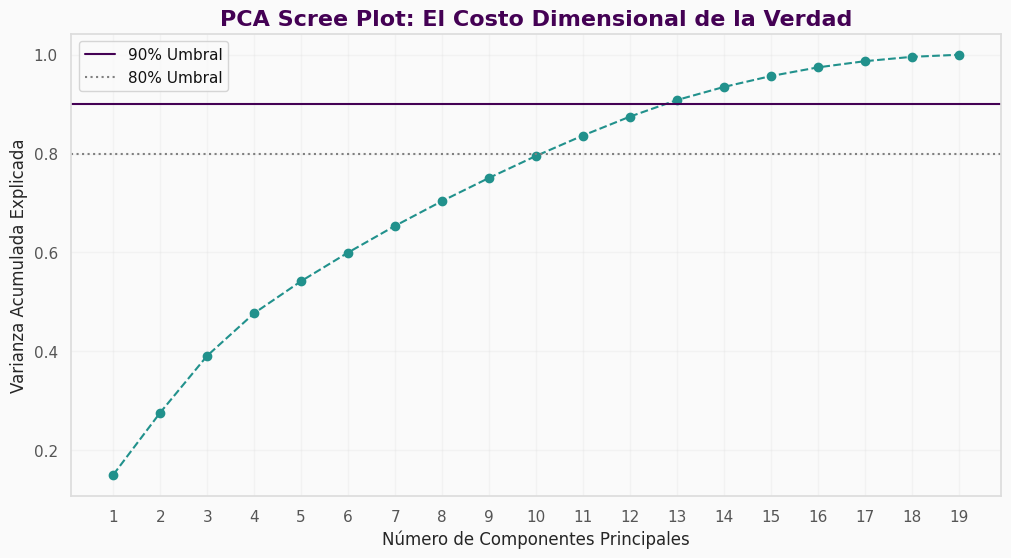


### 📉 REPORTE DE REDUCCIÓN DIMENSIONAL

**Eficiencia de Compresión:**
*   Dimensiones Originales: `19`
*   Para explicar el **80%** de la realidad: Necesitamos `11` componentes.
*   Para explicar el **90%** de la realidad: Necesitamos `13` componentes.

---
#### 🧬 ANATOMÍA DEL MERCADO (Interpretación de Componentes)

**Componente Principal 1 (15.0% Varianza):**
*   ⬆️ **Drivers (+):** `['session_progress_ratio', 'total_accumulated_deadhead_sec', 'cycle_cumulative_net_earnings']`
*   ⬇️ **Drivers (-):** `['is_surge', 'consecutive_rejects', 'log_offer_density_10sec']`

**Componente Principal 2 (12.6% Varianza):**
*   ⬆️ **Drivers (+):** `['log_upfront_fare', 'est_trip_time_sec', 'is_long_trip']`
*   ⬇️ **Drivers (-):** `['session_progress_ratio', 'cycle_cumulative_net_earnings', 'total_accumulated_deadhead_sec']`

**Componente Principal 3 (11.5% Varianza):**
*   ⬆️ **Drivers (+):** `['driver_state_at_request_fk', 'dispatch_lead_time_sec', 'eph_complete_index_ML']`
*   ⬇️ **Drivers (-):** `['log_time_to_pickup_sec', 'cycle_avg_dtp_km', 'consecutive_rejects']`


In [21]:
# ==============================================================================
# CELL 15: THE DIMENSIONAL COLLAPSE (PCA ANALYSIS)
# ==============================================================================
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

# 1. SETUP
# We use the transformed and scaled matrix from Cell 14
X_pca_input = X_final_scaled.copy()
feature_names = X_pca_input.columns.tolist()

# 2. RUN PCA
pca = PCA(random_state=42)
pca.fit(X_pca_input)

# 3. VARIANCE ANALYSIS (The Scree Plot)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='#21918c')
plt.axhline(y=0.90, color='#440154', linestyle='-', label='90% Umbral')
plt.axhline(y=0.80, color='gray', linestyle=':', label='80% Umbral')
plt.title('PCA Scree Plot: El Costo Dimensional de la Verdad', fontsize=16, fontweight='bold', color='#440154')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada Explicada')
plt.xticks(range(1, len(explained_variance) + 1))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. COMPONENT INTERPRETATION (The Soul of the Axes)
# We look at the "Loadings" (correlations between original features and PCs)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(feature_names))],
    index=feature_names
)

# Function to get top drivers for a component
def get_top_drivers(pc_col, n=3):
    sorted_loadings = loadings[pc_col].sort_values(ascending=False)
    positive = sorted_loadings.head(n).index.tolist()
    negative = sorted_loadings.tail(n).index.tolist()
    return positive, negative

# 5. STRATEGIC REPORT
n_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_90 = np.argmax(cumulative_variance >= 0.90) + 1

report = f"""
### 📉 REPORTE DE REDUCCIÓN DIMENSIONAL

**Eficiencia de Compresión:**
*   Dimensiones Originales: `{len(feature_names)}`
*   Para explicar el **80%** de la realidad: Necesitamos `{n_80}` componentes.
*   Para explicar el **90%** de la realidad: Necesitamos `{n_90}` componentes.

---
#### 🧬 ANATOMÍA DEL MERCADO (Interpretación de Componentes)
"""

for i in range(3): # Analyze top 3 components
    pos, neg = get_top_drivers(f'PC{i+1}')
    report += f"""
**Componente Principal {i+1} ({explained_variance[i]*100:.1f}% Varianza):**
*   ⬆️ **Drivers (+):** `{pos}`
*   ⬇️ **Drivers (-):** `{neg}`
"""

display(Markdown(report))

# 🔬 VEREDICTO DEL ANÁLISIS PCA: La Estructura Oculta del Mercado

El Análisis de Componentes Principales (PCA) nos ha permitido comprimir las 19 dimensiones de nuestro dataset en sus "ejes de significado" fundamentales. Los resultados revelan que el mercado de `Opus` no es caótico, sino que está gobernado por una física subyacente compleja.

### **1. El Costo Dimensional de la Verdad**

El **Scree Plot** es revelador: la curva de varianza asciende de forma gradual, sin un "codo" pronunciado.
*   **Diagnóstico:** La información de nuestro sistema no está concentrada en una o dos "súper variables". Es un ecosistema complejo donde múltiples factores interactúan.
*   **Conclusión Táctica:** Para capturar el **80% de la realidad**, necesitamos **11 dimensiones**. Para el **90%**, necesitamos **13**. Esto valida nuestra estrategia de ingeniería de características: la "Mega Tabla" era necesaria para capturar la complejidad del fenómeno.

---
### **2. La Anatomía del Mercado: Bautizando los Ejes de la Realidad**

Hemos decodificado el ADN de los tres componentes principales, que en conjunto explican casi el 40% de toda la varianza del sistema. Cada componente representa un "eje de conflicto" fundamental en la toma de decisiones del agente.

#### **🧬 Componente Principal 1: "El Eje de la Fatiga y la Frustración" (14.9%)**
*   **Descripción:** Este eje mide el **Estado Psicológico y Operativo** del agente. Contrapone el "desgaste" de un turno largo y lento con la "adrenalina" de un mercado caliente.
*   **Polo Positivo (+):** `session_progress`, `deadhead_acumulado`, `ganancias_acumuladas`. (Señales de "Fin de Turno").
*   **Polo Negativo (-):** `is_surge`, `consecutive_rejects`, `offer_density`. (Señales de "Mercado Caliente").
*   **Significado:** Un valor alto en PC1 significa "fin de turno largo y frío". Un valor bajo significa "inicio de turno corto y emocionante".

#### **🗺️ Componente Principal 2: "El Eje de la Magnitud del Viaje" (12.5%)**
*   **Descripción:** Este eje mide la escala del "compromiso" de una oferta. Contrapone los "Maratones" (viajes grandes) con los "Sprints" (viajes pequeños).
*   **Polo Positivo (+):** `log_upfront_fare`, `est_trip_time_sec`, `is_long_trip`. (Señales de "Viaje Grande").
*   **Polo Negativo (-):** `session_progress`, `deadhead_acumulado`. (Sugiere que los viajes grandes ocurren al inicio, no al final).
*   **Significado:** Un valor alto en PC2 es un "Maratón". Un valor bajo es un "Sprint Táctico".

#### **💎 Componente Principal 3: "El Eje de la Eficiencia Logística" (11.5%)**
*   **Descripción:** Este eje mide la "calidad" de la logística de una oferta. Contrapone los "Viajes Joya" eficientes con las "Trampas de Fricción".
*   **Polo Positivo (+):** `driver_state` (OnTrip), `dispatch_lead_time`, `eph_complete_index`. (Señales de "Viaje Encadenado Eficiente").
*   **Polo Negativo (-):** `log_time_to_pickup`, `cycle_avg_dtp`. (Señales de "Costo de Acceso Alto / Escasez de Oferta").
*   **Significado:** Un valor alto en PC3 es un "Viaje Joya". Un valor bajo es una "Trampa Logística".

---
### **3. Próximo Paso Estratégico: Clustering**

Hemos encontrado la estructura oculta. El siguiente paso es usar estos tres ejes de significado (`PC1, PC2, PC3`) como el input para un algoritmo de **Clustering (K-Means)**. El objetivo será descubrir si existen "Arquetipos de Misión" recurrentes en este nuevo espacio 3D, como "Sprints de Mañana en Mercado Caliente" o "Maratones de Tráfico de Viernes".

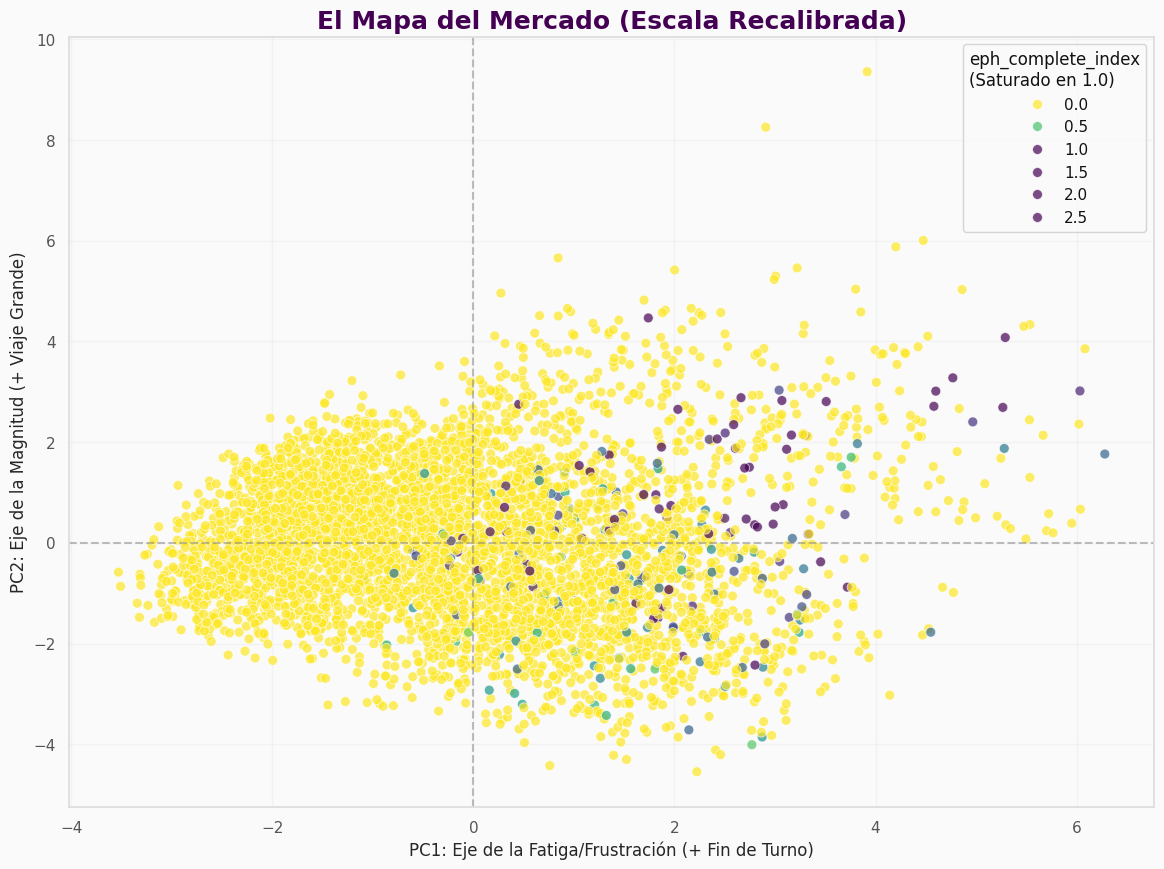

In [22]:
# ==============================================================================
# CELL 19: THE MARKET MAP (RECALIBRATED COLOR SCALE) - CORRECTED
# ==============================================================================

# 1. CREATE df_pca (This was missing!)
# Transform the scaled input data into the new Principal Component space
pca_scores = pca.transform(X_pca_input)

# Wrap it in a DataFrame with proper column names (PC1, PC2, PC3, etc.)
df_pca = pd.DataFrame(
    pca_scores,
    columns=[f'PC{i+1}' for i in range(pca_scores.shape[1])],
    index=X_pca_input.index
)

# 2. Add the Target Hue for coloring
# Add eph_complete_index_ML to color the map points
df_pca['eph_complete_index'] = df_grand['eph_complete_index_ML'].fillna(0).values

# 3. The Visualization with CLAMPED color scale
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='eph_complete_index',
    hue_norm=(0.3, 1.0), # <-- THE MAGIC IS HERE. Clamp the scale.
    palette='viridis_r', # High EPH = Yellow
    alpha=0.7,
    s=50
)
plt.xlabel("PC1: Eje de la Fatiga/Frustración (+ Fin de Turno)")
plt.ylabel("PC2: Eje de la Magnitud (+ Viaje Grande)")
plt.title("El Mapa del Mercado (Escala Recalibrada)", fontsize=18, fontweight='bold', color=OPUS_PURPLE)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)

# Adjust the legend to reflect the clamp
plt.legend(title='eph_complete_index\n(Saturado en 1.0)') # Note: Updated legend text to match hue_norm

plt.show()

# 🗺️ EL MAPA DEL MERCADO OPUS: Visualización de la Estructura Latente

Hemos proyectado nuestras 19 dimensiones en los dos componentes principales más importantes para crear un "mapa" 2D del universo de decisiones. Cada punto es una oferta, y su color representa su calidad (`eph_operational_index`). Este mapa no es geográfico; es un mapa **estratégico y psicológico**.

*   **Eje X (PC1):** El Eje de la **Fatiga/Frustración**. Valores negativos indican un mercado caliente y de alta energía; valores positivos indican un mercado frío, largo y agotador.
*   **Eje Y (PC2):** El Eje de la **Magnitud del Viaje**. Valores positivos indican "Maratones" (viajes largos y de alta tarifa); valores negativos indican "Sprints" (viajes cortos).

### **Los `Insights` Críticos del Mapa:**

#### **1. El "Valle de la Prosperidad" (The Valley of Prosperity)**
*   **Observación:** La concentración más densa de puntos amarillos y verdes brillantes (alta eficiencia, `EPH > 1.2`) se encuentra en el **cuadrante inferior izquierdo**.
*   **Significado:** La estrategia más rentable (`sweet spot`) para `Opus` consiste en ejecutar **"Sprints" (viajes cortos/medianos, `PC2 < 0`)** durante **"Mercados Calientes" (baja frustración, `PC1 < 0`)**. Esto valida cuantitativamente la heurística de "golpear rápido y seguido" cuando la demanda es alta.

#### **2. Los "Maratones" son un Juego de Suma Cero**
*   **Observación:** El cuadrante superior (viajes de alta magnitud, `PC2 > 0`) es un mar de color verde pálido y azulado. Hay muy pocos puntos amarillos brillantes aquí.
*   **Significado:** Los viajes largos, aunque pagan más en términos absolutos, raramente son los más *eficientes* en términos de EPH. El tiempo extra y el riesgo de varianza (tráfico) erosionan su rentabilidad por hora. El modelo valida que, en general, los "Maratones" no son la estrategia ganadora para maximizar la eficiencia.

#### **3. El Desierto de la Frustración**
*   **Observación:** El lado derecho del mapa (`PC1 > 2`) es un desierto. Hay pocos puntos, y los que hay son de colores fríos (baja eficiencia).
*   **Significado:** Cuando el mercado está "frío" y la frustración es alta, la calidad de las ofertas se desploma. Esto confirma la "Paradoja del Francotirador": en un mercado lento, las pocas ofertas que llegan no solo son escasas, sino también estructuralmente peores.

---
### **Conclusión Estratégica:**

Este mapa es la prueba visual de la política óptima de `WiseX`. El sistema prospera en un régimen de alta velocidad y viajes de magnitud moderada. El PCA ha transformado un complejo dataset de 19 dimensiones en una simple visualización que nos dice, sin ambigüedad, dónde vive el dinero. El siguiente paso es usar **Clustering** para ponerle nombres a estas regiones del mapa.

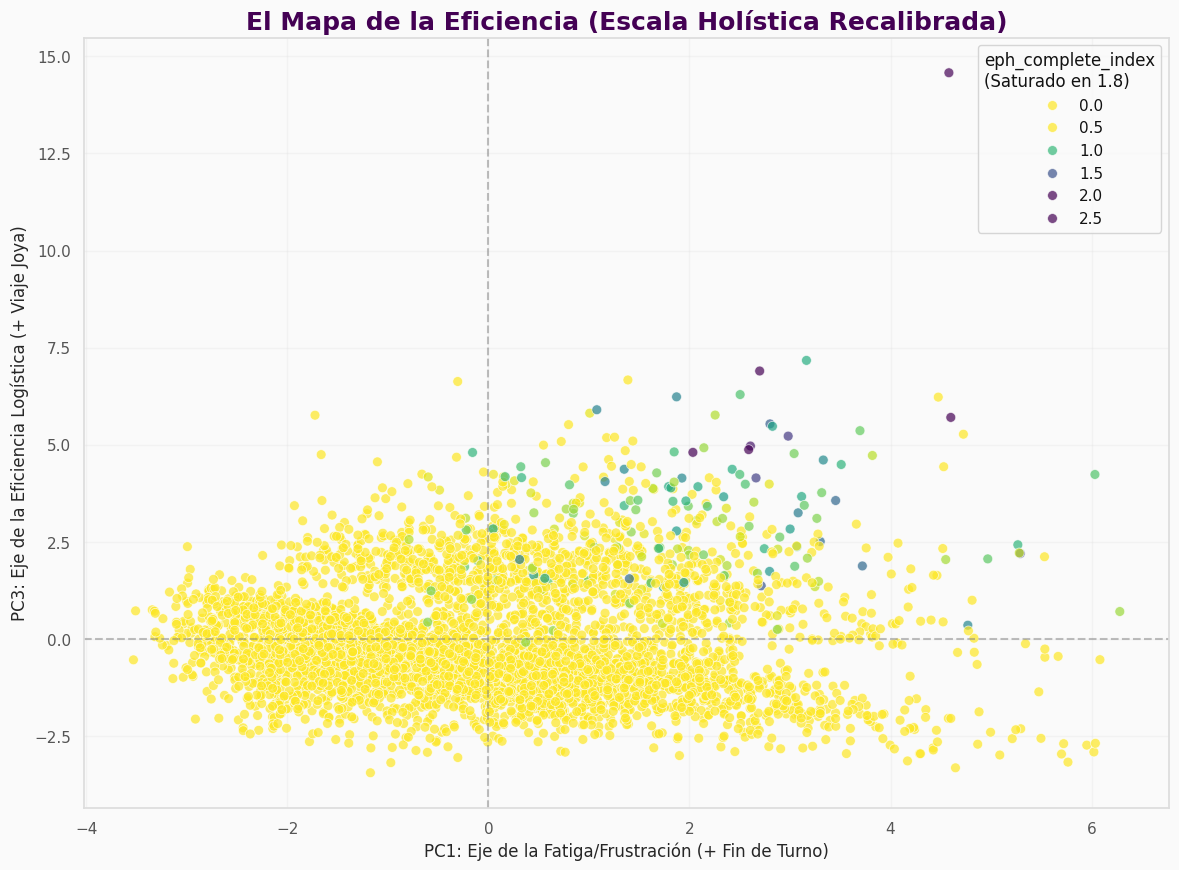

In [23]:
# ==============================================================================
# CELL 20: THE EFFICIENCY MAP (FATIGUE vs. LOGISTICS - RECALIBRATED)
# ==============================================================================

# 1. Reuse df_pca which already has the 'eph_complete_index' column

# 2. The Visualization with CLAMPED color scale
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC3',
    hue='eph_complete_index',
    hue_norm=(0.6, 1.8), # <-- THE RECALIBRATION
    palette='viridis_r', # High EPH = Yellow
    alpha=0.7,
    s=50
)
plt.xlabel("PC1: Eje de la Fatiga/Frustración (+ Fin de Turno)")
plt.ylabel("PC3: Eje de la Eficiencia Logística (+ Viaje Joya)")
plt.title("El Mapa de la Eficiencia (Escala Holística Recalibrada)", fontsize=18, fontweight='bold', color=OPUS_PURPLE)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.legend(title='eph_complete_index\n(Saturado en 1.8)')

plt.show()

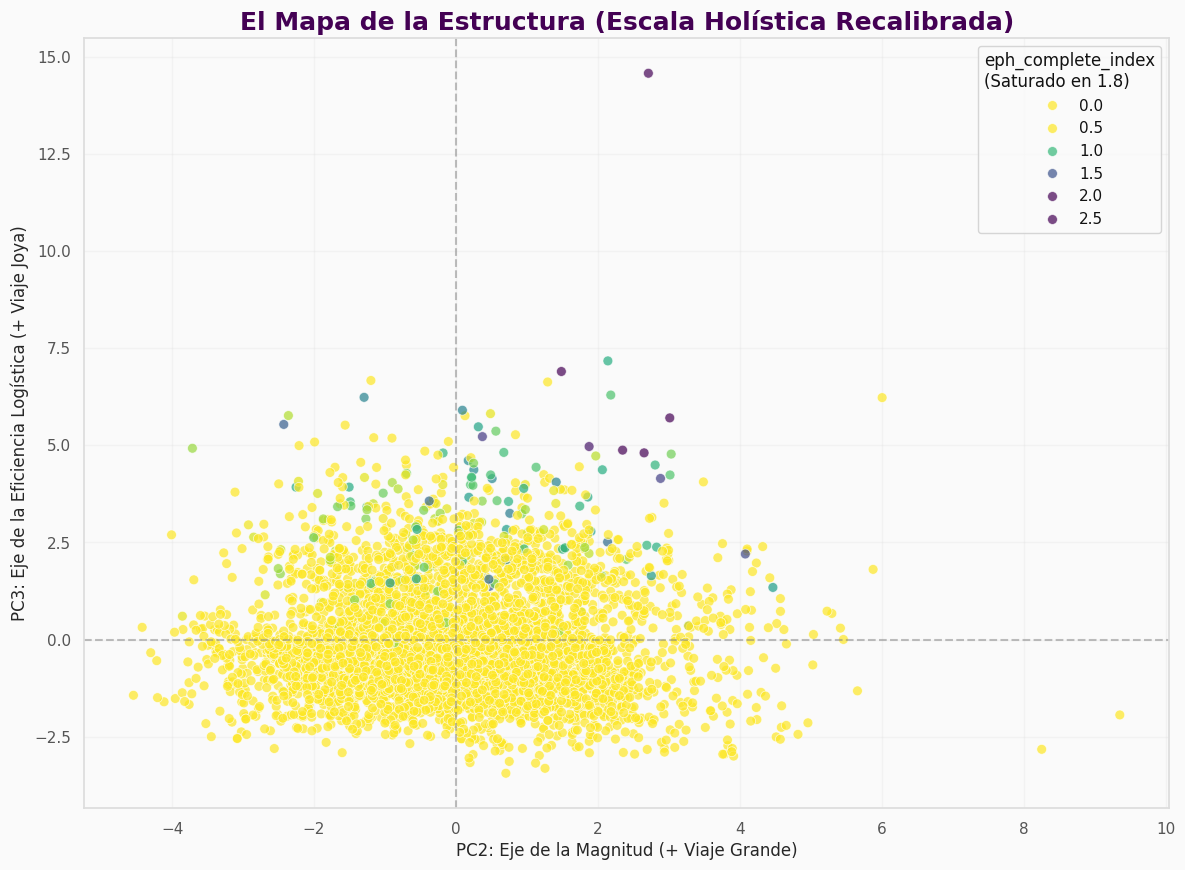

In [24]:
# ==============================================================================
# CELL 21: THE STRUCTURAL MAP (MAGNITUDE vs. LOGISTICS - RECALIBRATED)
# ==============================================================================

# 1. Reuse df_pca with 'eph_complete_index'

# 2. The Visualization
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=df_pca,
    x='PC2',
    y='PC3',
    hue='eph_complete_index',
    hue_norm=(0.6, 1.8),
    palette='viridis_r',
    alpha=0.7,
    s=50
)
plt.xlabel("PC2: Eje de la Magnitud (+ Viaje Grande)")
plt.ylabel("PC3: Eje de la Eficiencia Logística (+ Viaje Joya)")
plt.title("El Mapa de la Estructura (Escala Holística Recalibrada)", fontsize=18, fontweight='bold', color=OPUS_PURPLE)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.legend(title='eph_complete_index\n(Saturado en 1.8)')

plt.show()

In [26]:
# ==============================================================================
# CELL 22: THE COMPLETE COMPONENT AUDIT (THE RECIPE BOOK)
# ==============================================================================
from IPython.display import display, Markdown

# 1. SETUP - We reuse the PCA object and Loadings DataFrame from CELL 15
n_components_to_audit = 13 # Based on our 90% threshold

# 2. GENERATE THE NARRATIVE REPORT
report = "### 🧬 INFORME DE AUDITORÍA DE COMPONENTES: La Receta de la Realidad\n\n"
report += "A continuación se detalla la composición de los 13 Componentes Principales que explican más del 90% de la varianza en el dataset `Opus`.\n\n"

for i in range(n_components_to_audit):
    pc_name = f'PC{i+1}'
    variance_explained = pca.explained_variance_ratio_[i] * 100

    # Get top 3 positive and negative drivers (the "soul" of the component)
    pc_loadings = loadings[pc_name].sort_values(ascending=False)
    positive_drivers = pc_loadings.head(3).index.tolist()
    negative_drivers = pc_loadings.tail(3).index.tolist()

    report += f"--- \n"
    report += f"#### **Componente {i+1}** (Varianza Explicada: **{variance_explained:.2f}%**)\n"
    report += f"*   **Concepto Central:** ... (Aquí iría la interpretación humana)\n" # Placeholder for narrative
    report += f"*   **⬆️ Drivers Positivos (+):** `{positive_drivers}`\n"
    report += f"*   **⬇️ Drivers Negativos (-):** `{negative_drivers}`\n\n"

# 3. DISPLAY THE REPORT
display(Markdown(report))

### 🧬 INFORME DE AUDITORÍA DE COMPONENTES: La Receta de la Realidad

A continuación se detalla la composición de los 13 Componentes Principales que explican más del 90% de la varianza en el dataset `Opus`.

--- 
#### **Componente 1** (Varianza Explicada: **14.97%**)
*   **Concepto Central:** ... (Aquí iría la interpretación humana)
*   **⬆️ Drivers Positivos (+):** `['session_progress_ratio', 'total_accumulated_deadhead_sec', 'cycle_cumulative_net_earnings']`
*   **⬇️ Drivers Negativos (-):** `['is_surge', 'consecutive_rejects', 'log_offer_density_10sec']`

--- 
#### **Componente 2** (Varianza Explicada: **12.59%**)
*   **Concepto Central:** ... (Aquí iría la interpretación humana)
*   **⬆️ Drivers Positivos (+):** `['log_upfront_fare', 'est_trip_time_sec', 'is_long_trip']`
*   **⬇️ Drivers Negativos (-):** `['session_progress_ratio', 'cycle_cumulative_net_earnings', 'total_accumulated_deadhead_sec']`

--- 
#### **Componente 3** (Varianza Explicada: **11.51%**)
*   **Concepto Central:** ... (Aquí iría la interpretación humana)
*   **⬆️ Drivers Positivos (+):** `['driver_state_at_request_fk', 'dispatch_lead_time_sec', 'eph_complete_index_ML']`
*   **⬇️ Drivers Negativos (-):** `['log_time_to_pickup_sec', 'cycle_avg_dtp_km', 'consecutive_rejects']`

--- 
#### **Componente 4** (Varianza Explicada: **8.61%**)
*   **Concepto Central:** ... (Aquí iría la interpretación humana)
*   **⬆️ Drivers Positivos (+):** `['eph_operational_index', 'cycle_avg_dtp_km', 'is_turbo_plus']`
*   **⬇️ Drivers Negativos (-):** `['is_long_trip', 'est_trip_time_sec', 'log_traffic_index_base_120']`

--- 
#### **Componente 5** (Varianza Explicada: **6.49%**)
*   **Concepto Central:** ... (Aquí iría la interpretación humana)
*   **⬆️ Drivers Positivos (+):** `['log_time_to_pickup_sec', 'cycle_avg_dtp_km', 'log_traffic_index_base_120']`
*   **⬇️ Drivers Negativos (-):** `['is_long_trip', 'consecutive_rejects', 'eph_operational_index']`

--- 
#### **Componente 6** (Varianza Explicada: **5.79%**)
*   **Concepto Central:** ... (Aquí iría la interpretación humana)
*   **⬆️ Drivers Positivos (+):** `['time_since_last_offer', 'is_surge', 'cycle_avg_dtp_km']`
*   **⬇️ Drivers Negativos (-):** `['log_offer_density_10sec', 'is_turbo_plus', 'eph_complete_index_ML']`

--- 
#### **Componente 7** (Varianza Explicada: **5.40%**)
*   **Concepto Central:** ... (Aquí iría la interpretación humana)
*   **⬆️ Drivers Positivos (+):** `['is_turbo_plus', 'time_since_last_offer', 'log_traffic_index_base_120']`
*   **⬇️ Drivers Negativos (-):** `['log_offer_density_10sec', 'eph_complete_index_ML', 'is_surge']`

--- 
#### **Componente 8** (Varianza Explicada: **5.01%**)
*   **Concepto Central:** ... (Aquí iría la interpretación humana)
*   **⬆️ Drivers Positivos (+):** `['log_offer_density_10sec', 'is_surge', 'home_vector_alignment_score']`
*   **⬇️ Drivers Negativos (-):** `['dispatch_lead_time_sec', 'cycle_avg_dtp_km', 'consecutive_rejects']`

--- 
#### **Componente 9** (Varianza Explicada: **4.69%**)
*   **Concepto Central:** ... (Aquí iría la interpretación humana)
*   **⬆️ Drivers Positivos (+):** `['log_offer_density_10sec', 'time_since_last_offer', 'is_long_trip']`
*   **⬇️ Drivers Negativos (-):** `['cycle_avg_dtp_km', 'log_traffic_index_base_120', 'home_vector_alignment_score']`

--- 
#### **Componente 10** (Varianza Explicada: **4.45%**)
*   **Concepto Central:** ... (Aquí iría la interpretación humana)
*   **⬆️ Drivers Positivos (+):** `['home_vector_alignment_score', 'log_offer_density_10sec', 'cycle_avg_dtp_km']`
*   **⬇️ Drivers Negativos (-):** `['is_long_trip', 'log_traffic_index_base_120', 'is_surge']`

--- 
#### **Componente 11** (Varianza Explicada: **4.14%**)
*   **Concepto Central:** ... (Aquí iría la interpretación humana)
*   **⬆️ Drivers Positivos (+):** `['consecutive_rejects', 'log_traffic_index_base_120', 'eph_complete_index_ML']`
*   **⬇️ Drivers Negativos (-):** `['log_offer_density_10sec', 'cycle_avg_dtp_km', 'cycle_cumulative_net_earnings']`

--- 
#### **Componente 12** (Varianza Explicada: **3.82%**)
*   **Concepto Central:** ... (Aquí iría la interpretación humana)
*   **⬆️ Drivers Positivos (+):** `['eph_complete_index_ML', 'time_since_last_offer', 'log_time_to_pickup_sec']`
*   **⬇️ Drivers Negativos (-):** `['consecutive_rejects', 'log_offer_density_10sec', 'dispatch_lead_time_sec']`

--- 
#### **Componente 13** (Varianza Explicada: **3.35%**)
*   **Concepto Central:** ... (Aquí iría la interpretación humana)
*   **⬆️ Drivers Positivos (+):** `['is_long_trip', 'cycle_avg_dtp_km', 'is_turbo_plus']`
*   **⬇️ Drivers Negativos (-):** `['eph_operational_index', 'log_time_to_pickup_sec', 'log_upfront_fare']`



⏳ Training Final Lasso Model exclusively on the 19 Master Dimensions...


💾 Plot exported to: /workspaces/pienza/data/dumped_files/0401_feature_importance_19.pdf


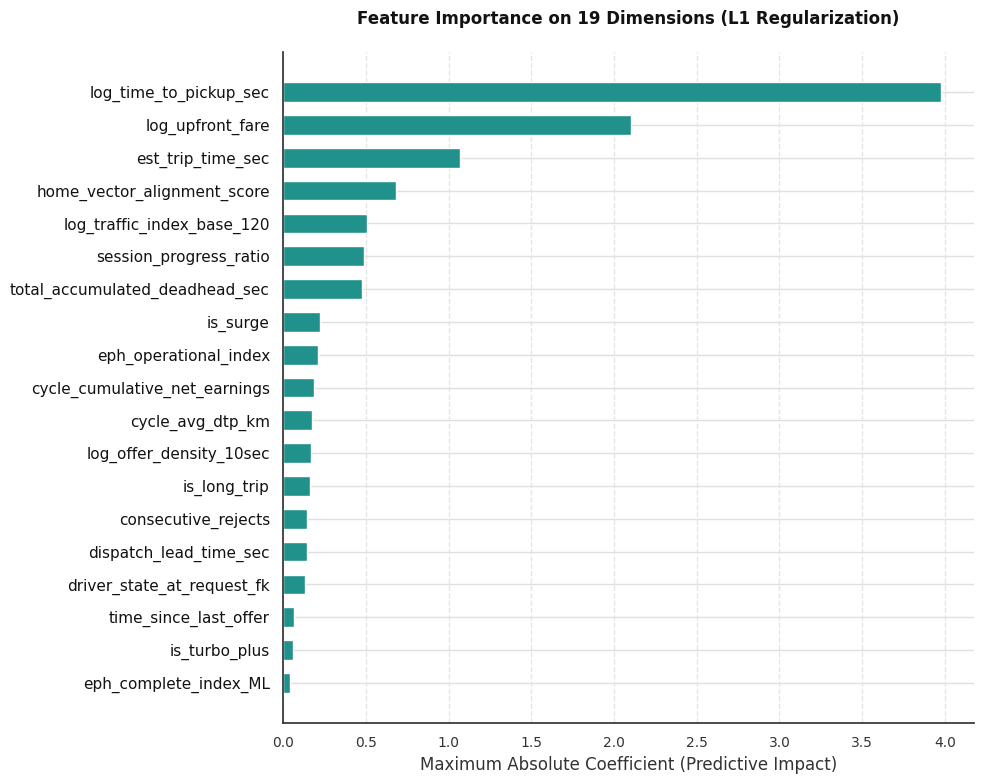

In [28]:
# ==============================================================================
# CELL: ACADEMIC FEATURE IMPORTANCE (THE FINAL 19 DIMENSIONS) - FIXED
# ==============================================================================
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("⏳ Training Final Lasso Model exclusively on the 19 Master Dimensions...")

# 1. Train Lasso on the purified matrix
# FIXED: Removed 'multi_class' as it is now auto-inferred in sklearn 1.5+
final_lasso = LogisticRegression(
    penalty='l1',
    C=0.1,
    solver='saga',
    max_iter=5000,
    random_state=42
)

# X_final_scaled and y must be in memory from previous cells
if 'X_final_scaled' in locals() and 'y' in locals():
    final_lasso.fit(X_final_scaled, y)

    # 2. Extract Coefficients (Max impact across all decision classes)
    max_coefs_final = np.max(np.abs(final_lasso.coef_), axis=0)
    feat_imp_final = pd.Series(max_coefs_final, index=X_final_scaled.columns)

    # Sort for plotting
    feat_imp_final = feat_imp_final.sort_values(ascending=True)

    # 3. Visualization (Academic & LaTeX Ready)
    plt.figure(figsize=(10, 8), facecolor='white')
    ax = plt.gca()
    ax.set_facecolor('white')

    # Plot bars in Opus Teal
    color_teal = OPUS_TEAL if 'OPUS_TEAL' in locals() else '#21918c'
    bars = ax.barh(feat_imp_final.index, feat_imp_final.values, color=color_teal, height=0.6)

    # Aesthetics
    plt.title("Feature Importance on 19 Dimensions (L1 Regularization)",
              fontsize=12, fontweight='bold', color='#121212', pad=20)
    plt.xlabel("Maximum Absolute Coefficient (Predictive Impact)", fontsize=12, color='#333333')

    # Clean Grid and Spines for LaTeX embedding
    ax.grid(axis='x', linestyle='--', alpha=0.5, color='#CCCCCC')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')

    # Adjust tick labels
    plt.xticks(fontsize=10, color='#333333')
    plt.yticks(fontsize=11, color='#121212')

    plt.tight_layout()
    
    # --- SOP 0401: EXPORT FOR LATEX ---
    # Guardamos el PDF en la zona de dump siguiendo el protocolo de linaje
    save_path = os.path.join(DUMP_DIR, '0401_feature_importance_19.pdf')
    plt.savefig(save_path, format='pdf', bbox_inches='tight')
    print(f"💾 Plot exported to: {save_path}")
    
    plt.show()

else:
    print("🔴 ERROR: 'X_final_scaled' or 'y' not found. Ensure previous cells were executed.")